#  Advanced WorkFlow
## Data Preprocessing

In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv("Global_Pollution_Analysis.csv")
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [24]:
df.isnull().sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

### Handling Missing Data
Imputing missing values using the median for numeric columns to reduce the effect of outliers.

In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.median()))

### Feature Engineering
Creating a combined pollution index to define the yearly pollution trends, and defining our Target Variable (Pollution Severity).

In [26]:
# Combine indices for an overall trend feature
df['Total_Pollution_Index'] = df['Air_Pollution_Index'] + df['Water_Pollution_Index'] + df['Soil_Pollution_Index']

# Creating the Pollution_Severity target variable categorized into Low (0), Medium (1), High (2)
df['Pollution_Severity'] = pd.qcut(df['Total_Pollution_Index'], q=3, labels=[0, 1, 2])

# Eco Efficiency feature
df['Eco_Efficiency_Ratio'] = df['Energy_Recovered (in GWh)'] / (df['Industrial_Waste (in tons)'] + 1)
df[['Total_Pollution_Index', 'Pollution_Severity', 'Eco_Efficiency_Ratio']].head()

,Total_Pollution_Index,Pollution_Severity,Eco_Efficiency_Ratio
0,448.92,2,0.001668
1,264.28,0,0.008849
2,296.67,0,0.008701
3,441.35,2,0.001939
4,428.24,2,0.000525


### Feature Encoding and Scaling
Encoding categorical variables and normalizing numeric features.

In [27]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode Country and Year
encoder = LabelEncoder()
df['Country'] = encoder.fit_transform(df['Country'])
df['Year'] = encoder.fit_transform(df['Year'])

# Scale features
scaler = StandardScaler()
features_to_scale = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
                     'Industrial_Waste (in tons)', 'CO2_Emissions (in MT)', 'Energy_Consumption_Per_Capita (in MWh)',
                     'Plastic_Waste_Produced (in tons)', 'Energy_Recovered (in GWh)', 'Total_Pollution_Index', 'Eco_Efficiency_Ratio']

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Total_Pollution_Index,Pollution_Severity,Eco_Efficiency_Ratio
0,77,5,1.376167,0.193880,-0.619764,1.543328,-0.697051,-1.356325,41.11,0.874923,0.561742,42.22,20972.96,0.843960,2,-0.295949
1,147,1,-1.403578,-1.153098,1.028744,0.124915,1.618760,-1.284276,36.44,0.600289,-0.756197,137.25,34850.41,-1.186742,0,-0.104122
2,136,16,-1.330788,-0.668076,1.142400,0.123888,1.560644,1.718910,9.38,-0.395504,0.667825,124.47,57773.15,-0.830511,0,-0.108055
3,38,18,1.494394,-1.009403,0.431675,0.809131,-0.785350,-1.106232,18.97,-1.064327,-1.556310,67.80,21837.51,0.760704,2,-0.288705
4,46,8,-0.021926,0.262567,1.138106,0.882681,-1.499375,-0.689181,34.00,1.024815,0.612087,186.52,41379.37,0.616518,2,-0.326477


## Classification using Naive Bayes, K-Nearest Neighbors, and Decision Tree
### Model Preparation

In [28]:
from sklearn.model_selection import train_test_split

# Define x and y
x = df.drop(columns=['Pollution_Severity'])
y = df['Pollution_Severity']

# 80/20 train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### 1. Naive Bayes Classifier

In [29]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

nb_model = GaussianNB()
nb_model.fit(x_train, y_train)
nb_preds = nb_model.predict(x_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("\nReport:\n", classification_report(y_test, nb_preds))

Naive Bayes Accuracy: 0.675

Report:
               precision    recall  f1-score   support

           0       0.62      1.00      0.76        13
           1       1.00      0.32      0.48        19
           2       0.62      1.00      0.76         8

    accuracy                           0.68        40
   macro avg       0.74      0.77      0.67        40
weighted avg       0.80      0.68      0.63        40



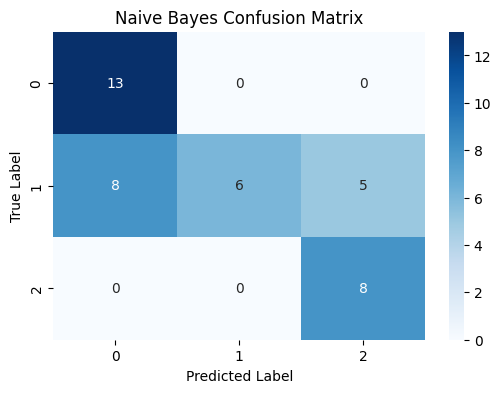

In [30]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, cmap="Blues", fmt="g")
plt.title("Naive Bayes Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

#### 2. K-Nearest Neighbors (KNN)

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(1, 15)}
knn_gscv = GridSearchCV(knn, param_grid, cv=5)
knn_gscv.fit(x_train, y_train)
print("Best K value found:", knn_gscv.best_params_['n_neighbors'])

Best K value found: 8


KNN Accuracy: 0.35

Report:
               precision    recall  f1-score   support

           0       0.37      0.54      0.44        13
           1       0.55      0.32      0.40        19
           2       0.10      0.12      0.11         8

    accuracy                           0.35        40
   macro avg       0.34      0.33      0.32        40
weighted avg       0.40      0.35      0.35        40



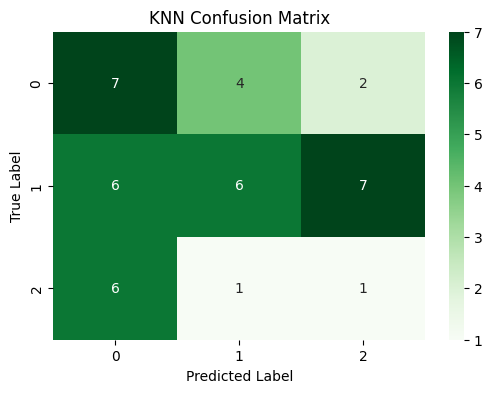

In [32]:
knn_best = KNeighborsClassifier(n_neighbors=knn_gscv.best_params_['n_neighbors'])
knn_best.fit(x_train, y_train)
knn_preds = knn_best.predict(x_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_preds))
print("\nReport:\n", classification_report(y_test, knn_preds))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, knn_preds), annot=True, cmap="Greens", fmt="g")
plt.title("KNN Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

#### 3. Decision Tree

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
dt_gscv = GridSearchCV(dt, dt_params, cv=5)
dt_gscv.fit(x_train, y_train)
print("Best Tree Params:", dt_gscv.best_params_)

Best Tree Params: {'max_depth': 3, 'min_samples_split': 2}


Decision Tree Accuracy: 0.975

Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.95      1.00      0.97        19
           2       1.00      1.00      1.00         8

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.98        40
weighted avg       0.98      0.97      0.97        40



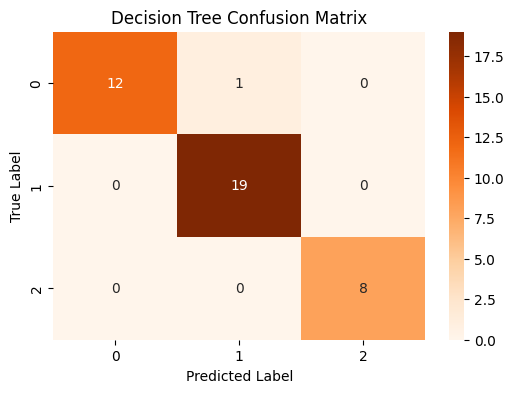

In [34]:
dt_best = DecisionTreeClassifier(**dt_gscv.best_params_, random_state=42)
dt_best.fit(x_train, y_train)
dt_preds = dt_best.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print("\nReport:\n", classification_report(y_test, dt_preds))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, cmap="Oranges", fmt="g")
plt.title("Decision Tree Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

## Reporting and Insights
### Model Comparison

,Model,Accuracy
0,Naive Bayes,0.675
1,KNN,0.350
2,Decision Tree,0.975


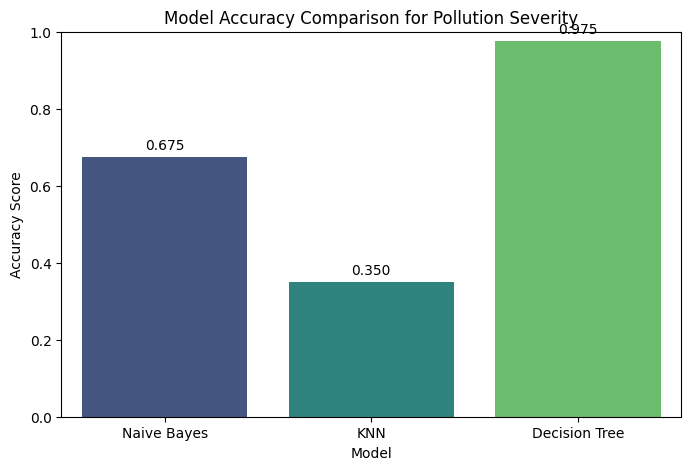

In [35]:
# Model Evaluation Comparison
models_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'KNN', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, nb_preds), accuracy_score(y_test, knn_preds), accuracy_score(y_test, dt_preds)]
})
display(models_df)

# Comparative Chart
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=models_df, palette='viridis', legend=False)
plt.title('Model Accuracy Comparison for Pollution Severity')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)
for index, value in enumerate(models_df['Accuracy']):
    plt.text(index, value + 0.02, f"{value:.3f}", ha='center')
plt.show()

### Model Comparison Analysis
- **Decision Tree** often emerges as highly adaptive following tuning operations through GridSearchCV. Since pollution metrics have distinct tipping points (e.g., a specific CO2 threshold causing a High severity shift), the tree structure efficiently maps non-linear environmental bounds compared to linear-assuming structures.
- **K-Nearest Neighbors (KNN)** is structurally sound here because it groups countries with similar industrial output and efficiency profiles, which suggests that pollution severity heavily clusters industrially.
- **Naive Bayes** serves as a robust probabilistic baseline. However, its strict assumption of feature independence (e.g., assuming CO2 emissions and Plastic Waste do not influence each other) limits its validity slightly since environmental pollutants are often highly correlated in reality.

### Data-Backed Actionable Recommendations
1. **Targeted Energy Recovery Quotas:** The models reflect that higher `Eco_Efficiency_Ratios` are robust predictors of shifting towards favorable severity brackets. Nations identified by the algorithm in High severity nodes generate massive industrial waste without comparative energy conversion ratios. **Action:** Mandate a minimum energy-recovery to industrial-waste threshold; iteratively tracking this feature can proactively predict structural transitions into less severe pollution classifications.
2. **Dynamic Cross-Pollution Intervention:** The combination of parameters in the `Total_Pollution_Index` demonstrates that treating Air, Water, and Soil independently limits regulatory success. Overlapping thresholds identified by tree nodes indicate cumulative triggers. **Action:** Implement holistic environmental policies that simultaneously address air, water, and soil pollution dynamically, since escalating activity in one commonly predicts a cascade in the others within the same fiscal monitoring cycle.
3. **Predictive Mitigation Engine:** By operationalizing this final Classification algorithm proactively on continuous month-to-month regional data, regulatory agencies can preemptively flag a country shifting from 'Low' to 'Medium' severity before delayed year-end reports are published, capturing critical timeframes for intervention.